In [1]:
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
matplotlib.use('module://matplotlib_inline.backend_inline')
import yaml
import time
import pickle as pkl
import os
import sys
import numpy as np
from matplotlib import cm
from scipy import signal
from scipy.signal import butter, welch, filtfilt, periodogram, savgol_filter
import pandas as pd
import glob
from scipy.optimize import curve_fit
from scipy.optimize import fminbound
import scipy.linalg as linalg
import scipy as sp
# sys.path.append("/home/cryo/.local/lib/python3.10/site-packages/")
# import nbimporter

plt.ion()
%matplotlib inline

SMALL_SIZE = 14
MEDIUM_SIZE = 16
BIGGER_SIZE = 18

plt.rc('font', size=SMALL_SIZE, family='serif')          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE, labelsize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE, facecolor='white') 

# Import useful functions

In [3]:
# Import useful wrapper functions. This doesn't work

sys.path.append("/home/cryo/docker/pysmurf/dev/v8.0.0-rc3_rfsoc/pysmurf/scratch/adroster")
from utils import *

# Define useful functions

In [6]:
def welch_IQ(iq, fs,  plot=True, welch_nperseg=2**18, title='', show_plot=True):
    i = iq.real
    q = iq.imag
    ffi, pxxi = welch(i,fs=fs, nperseg=welch_nperseg)
    ffq, pxxq = welch(q,fs=fs, nperseg=welch_nperseg)

    # scale to dBc/Hz by the voltage magnitude
    magfac = np.mean(q)**2 + np.mean(i)**2
    pxxi_dbc = 10. * np.log10(pxxi / magfac)
    pxxq_dbc = 10. * np.log10(pxxq / magfac)


    if plot:
        plt.gca().semilogx(ffi,pxxi_dbc,linestyle='-',label=f'i {title}')
        plt.gca().semilogx(ffq,pxxq_dbc, linestyle='--',label=f'q {title}')
        plt.ylabel('dBc/Hz')
        plt.xlabel('Frequency (Hz)')
        plt.title(title)
        plt.legend(loc='lower left')
        if show_plot: plt.show()
    return

def freqSweep(S, band, start_freq=-250, stop_freq=250, subband=None, tone_power=None, n_avg=1, makeplot=False):
    """
    Inputs:
    S (obj): PySMuRF control instance
    start_freq (int): start frequency of sweep in the IF [MHz]
    stop_freq (int): stop frequency of sweep in the IF [MHz]
    subband:
    tone_power (int): int between 0 and 15. Each integer is 0.5 dBm of power. Not much dynamic range here. Defaults to 12 due to config file.
    n_avg (int): nubmer of times to average. this is a sweep-to-sweep average, analogous to averaging on a VNA
    makeplot (bool): 

    Outputs:
    freqs (ndarray): real-valued 1D array of frequenies (RF, not IF)
    resp_avg (ndarray): complex-valued 1D array of response
    """
    #adapted from S.find_freq()
    band_center = S.get_band_center_mhz(band)
    if subband is None:
        start_subband = S.freq_to_subband(band, band_center + start_freq)[0]
        stop_subband = S.freq_to_subband(band, band_center + stop_freq)[0]
        step = 1
        if stop_subband < start_subband:
            step = -1
        subband = np.arange(start_subband, stop_subband+1, step)
    else:
        sb, sbc = S.get_subband_centers(band)
        start_freq = sbc[subband[0]]
        stop_freq  = sbc[subband[-1]]

    # Turn off all tones in this band first.  May want to make
    # this only turn off tones in each sub-band before sweeping,
    # instead?
    S.band_off(band)

    if tone_power is None:
        tone_power = S._amplitude_scale[band]
        S.log('No tone_power given. Using value in config ' +
                 f'file: {tone_power}')

    #the following for loop does an amplitude sweep n_avg times, reads the response, and addes the response array to resp_tot
    #resp_tot has shape (n_avg, 31*n_channels). n_channels is the number of processed channels + 1; there are 31 frequencies per channel.
    S.log(f'Sweeping across frequencies {start_freq + band_center}MHz to {stop_freq + band_center}MHz. Averaging {n_avg} traces.')
    BW_MHz = 500
    freqs_per_channel = 31
    n_channels = int(np.ceil((S.get_number_processed_channels(band))*(stop_freq - start_freq)/BW_MHz)+1)
    resp_shape = (n_avg, freqs_per_channel*n_channels)
    #resp_arr = np.zeros(resp_shape, dtype = np.complex_)
    resp_arr = []
    for n in range(n_avg):
        f, resp = S.full_band_ampl_sweep(band, subband, tone_power, n_read=2) #n_read doesn't actually do anything; must be legacy code from previous SMuRF implementations
        
        #below is adapted from S.find_all_peak()
        # Stack all the frequency and response data into a
        # Frequency array is the same on every iteration, so only need to find & sort frequencies once
        if n == 0:
            sb, _ = np.where(f !=0)
            idx = np.unique(sb)
            f_stack = np.ravel(f[idx])
            # Frequency is interleaved, so sort it
            s = np.argsort(f_stack)
            f_stack = f_stack[s]
            freqs = f_stack

            # convert frequencies from IF to the RF
            if band is not None:
                bandCenterMHz = S.get_band_center_mhz(band)
                scale = 1
                if np.max(f_stack) > 1.0E8:
                    self.log('Frequency is probably in Hz. Converting to MHz')
                    scale = 1.0E-6
                freq_rf = bandCenterMHz - freqs*scale
            else:
                freq_rf = bandCenterMHz - freqs
            
        r_stack = np.ravel(resp[idx])
    
        # response is also interleaved, so sort it
        r_stack = r_stack[s]

        #append the sorted & stacked response array to resp_arr
        #resp_arr[n,:] = r_stack
        resp_arr.append(r_stack)

    #Frequencies are just f_stack; Average the response

    resp_arr = np.array(resp_arr)
    resp_avg = np.mean(resp_arr, axis=0)
    
    # Break apart the data to find phase, deriv of phase
    angle = np.unwrap(np.angle(resp_avg))
    x = np.arange(len(angle))
    p1 = np.poly1d(np.polyfit(x, angle, 1))
    angle -= p1(x)
    grad_kernel_width = 8
    grad = np.convolve(angle, np.repeat([1,-1], grad_kernel_width), mode='same')
    #grad_kernel_width is number of samples to take after a point to calculate gradient; default is 8

    #find the amplitude
    amp = np.abs(resp_avg)
    
    #calculating rolling median. Adapted from S.find_peaks()   
    # Calculate the rolling median. This uses pandas. This is analogous to smoothing on a VNA.
    import pandas as pd
    med_amp = pd.Series(amp).rolling(window=50, center=True, min_periods=1).median()

    # convert frequencies from IF to the RF
    if band is not None:
        bandCenterMHz = S.get_band_center_mhz(band)
        scale = 1
        if np.max(f_stack) > 1.0E8:
            self.log('Frequency is probably in Hz. Converting to MHz')
            scale = 1.0E-6
        freq_rf = bandCenterMHz - freqs*scale
    else:
        freq_rf = bandCenterMHz - freqs
    
    #plotting
    if makeplot:
        plt.ion()

        fig, ax = plt.subplots(2, figsize=(8,6), sharex=True)

        # Plot response
        ax[0].plot(freq_rf, amp)
        ax[0].plot(freq_rf, med_amp)

        ax[1].plot(freq_rf, grad)
        ax[1].set_ylim(-2, 20)

        ax[0].set_ylabel('Amp.')
        ax[1].set_ylabel('Deriv Phase')
        ax[1].set_xlabel('Freq. [MHz]')

        # Text label
        text = ''
        if band is not None:
            text += f'Band: {band}' + '\n'
            text += f'Center Freq: {bandCenterMHz} MHz' + '\n'
        ax[0].text(.025, .975, text, transform=ax[0].transAxes, ha='left',
            va='top')

    
    return freq_rf, resp_avg

# find the frequency between parity bands
def lorentzian(f, f0, Gc, Gr, g, Omega, slope):
    Delta = 2*np.pi*(f - f0)
    S21 = 1 - (Gc/2/g)*(1-Delta*1j/g)/(1+(Delta/g)**2+(2*np.pi*Omega)**2/g/Gr) + slope*Delta
    return S21
    
def invertedDoubleLorentzian(f, f0_1, f0_2, Gc_1, GC_2, Gr_1, Gr_2, g_1, g_2, Omega_1, Omega_2, baseline, scale, slope):
    '''
    Eq. E22 in the design paper
    '''
    lorentzian1 = lorentzian(f, f0_1, Gc_1, Gr_1, g_1, Omega_1, slope)
    lorentzian2 = lorentzian(f, f0_2, Gc_2, Gr_2, g_2, Omega_2, slope)
    S21 = baseline + scale*(lorentzian1 + lorentzian2)
    return np.abs(S21)

def negInvertedDoubleLorentzian(f, f0_1, f0_2, Gc_1, GC_2, Gr_1, Gr_2, g_1, g_2, Omega_1, Omega_2, baseline, scale, slope):
    '''
    Eq. E22 in the design paper
    '''
    return -invertedDoubleLorentzian(f, f0_1, f0_2, Gc_1, GC_2, Gr_1, Gr_2, g_1, g_2, Omega_1, Omega_2, baseline, scale, slope)

def takeDebugData(S, band, channel, nsamp, plot=True, welch_nperseg=2**18, show_plot=True, channel_mode=0):
    timestamp = S.get_timestamp()
    filename = f'{timestamp}_multi_channel_b{band}'
    if channel is not None:
        filename = f'{timestamp}_single_channel_b{band}ch{channel:03}'
    i,q,sync = S.take_debug_data(band=band,channel=channel,rf_iq=True,nsamp=nsamp,filename=filename, single_channel_readout=channel_mode) 
    i = i / (1.2)
    q = q / (-1.2)
    iq = i + 1j * q
    if plot: 
        fs = S.get_channel_frequency_mhz(band) * 1.0E6
        welch_IQ(iq, fs, welch_nperseg, title=filename, show_plot=show_plot)
        ### save plots 
        fig = plt.gcf()
        #plt.savefig(f'/data/smurf_data/mkid_1tone_streaming_metadata/_Figs/{filename}_psd', fmt='tiff')
        plt.show()
    return iq, sync, filename

def butterworth_filter(data, fs, cutoff_hz=200, order=1):
    b, a = butter(N=order, Wn=cutoff_hz, btype='low', fs=fs)
    zi = sp.signal.lfilter_zi(b, a)
    filt_data, _ = sp.signal.lfilter(b, a, data, zi=zi*data[0])
    return filt_data

# Initialize a pysmurf control instance

In [5]:
import pysmurf.client
import epics
import os
import time

%matplotlib inline

epics_prefix="smurf_server_s3"
config_file=os.path.abspath("/usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg")
S = pysmurf.client.SmurfControl(epics_root=epics_prefix,cfg_file=config_file,setup=False,make_logfile=False,shelf_manager="shm-smrf-sp01")

## Dump versions of everything
# Python version
print(sys.version)
import pysmurf
pysmurf.__version__
cwd=os.getcwd()
os.chdir('/usr/local/src/pysmurf/')
#print(str(!git branch))
#print(!git rev-parse --short HEAD)
print(S.get_fpga_git_hash_short())
print(S.config.filename)

[ 2026-03-06 00:34:42 ]  ERROR : band 0 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-03-06 00:34:42 ]  ERROR : band 1 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-03-06 00:34:42 ]  ERROR : band 2 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-03-06 00:34:42 ]  ERROR : band 3 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-03-06 00:34:42 ]  ERROR : band 4 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-03-06 00:34:42 ]  ERROR : band 5 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-03-06 00:34:42 ]  ERROR : band 6 is present in pysmurf cfg file, but its bay is not enabled!
[ 2026-03-06 00:34:42 ]  ERROR : band 7 is present in pysmurf cfg file, but its bay is not enabled!
3.8.10 (default, Mar 13 2023, 10:26:41) 
[GCC 9.4.0]
9355e2a
/usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg


## Define the LO frequency

In [7]:
LO_freq_MHz = 9150

## Set SMuRF parameters

In [9]:
S.log_file

AttributeError: 'SmurfControl' object has no attribute 'log_file'

In [10]:
S.all_off()

[ 2026-03-06 00:35:29 ]  Turning off tones
[ 2026-03-06 00:35:48 ]  Turning off flux ramp
[ 2026-03-06 00:35:48 ]  Turning off all TES biases


In [11]:
S.get_band_center_mhz(band=0)

8400.0

The baseband center of 4250 MHz is a legacy number from old smurf versions. The RFSoC board has a baseband center of 750 MHz. But the LO mixes this up to 8.5 GHz (9250-750=8500.) Let's tell the software what's what:

In [13]:
S.set_band_center_mhz(0,LO_freq_MHz-750)

In [14]:
S.get_band_center_mhz(band=0)

8400.0

# Playing around with streaming

In [16]:
S.get_sample_frequency() #in Hz

1500.0

In [17]:
from pysmurf.client.util.SmurfFileReader import SmurfStreamReader
S._caput(f'{S.app_core}baySelStream', 0, write_log=True)
S._caput(f'{S.app_core}modeStream', 1,write_log=True)
print(f"baySelStream: {S._caget(f'{S.app_core}baySelStream',write_log=True)}")
print(f"modeStream: {S._caget(f'{S.app_core}modeStream',write_log=True)}")

[ 2026-03-06 00:41:47 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream 0
[ 2026-03-06 00:41:47 ]  caput smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream 1
[ 2026-03-06 00:41:47 ]  caget smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:baySelStream
[ 2026-03-06 00:41:47 ]  0
baySelStream: 0
[ 2026-03-06 00:41:47 ]  caget smurf_server_s3:AMCc:FpgaTopLevel:AppTop:AppCore:modeStream
[ 2026-03-06 00:41:47 ]  1
modeStream: 1


In [18]:
S.which_on(0)

array([], dtype=int64)

In [19]:
S.get_band_center_mhz(band=0)

8400.0

In [20]:
S.all_off()

[ 2026-03-06 00:42:07 ]  Turning off tones
[ 2026-03-06 00:42:23 ]  Turning off flux ramp
[ 2026-03-06 00:42:23 ]  Turning off all TES biases


In [21]:
S.set_fixed_tone(8380, 12)
S.set_fixed_tone(8420, 12)

(0, 272)

In [22]:
S.which_on(0)

array([272, 495])

In [23]:
S.get_number_processed_channels(0)

416

In [24]:
print('Pysmurf Client Version:',pysmurf.__version__)
print('Rogue Version:',S._caget(f'{epics_prefix}:AMCc:RogueVersion', as_string=True))
print('Pysmurf Core Version:', S._caget(f'{epics_prefix}:AMCc:SmurfApplication:SmurfVersion', as_string=True))
print('FPGA Git Hash Short:', S.get_fpga_git_hash_short())
print('Config file:', S.config.filename)
print('Cryocard FW Version:', S.C.get_fw_version())

Pysmurf Client Version: 9.0.0+30.g65b96dfc.dirty
Rogue Version: v4.11.11
Pysmurf Core Version: 9.0.0+24.g2b076d38.dirty
FPGA Git Hash Short: 9355e2a
Config file: /usr/local/src/pysmurf/cfg_files/lab1/experiment_lab1_rfsoc.cfg
Cryocard FW Version: (0, 0, 0)


In [25]:
fname = S.take_stream_data(10, IQ_mode = True)

[ 2026-03-06 00:42:36 ]  Starting to take data.
[ 2026-03-06 00:42:36 ]  Input downsample factor is None. Using value already in pyrogue: 20
[ 2026-03-06 00:42:36 ]  CryoCard.do_read failed, retry 1 / 5.
[ 2026-03-06 00:42:36 ]  CryoCard.do_read failed, retry 2 / 5.
[ 2026-03-06 00:42:36 ]  CryoCard.do_read failed, retry 3 / 5.
[ 2026-03-06 00:42:36 ]  CryoCard.do_read failed, retry 4 / 5.
[ 2026-03-06 00:42:36 ]  CryoCard.do_read failed, retry 5 / 5.
[ 2026-03-06 00:42:36 ]  flux_ramp_ac_dc_relay status: Failed to read from cryo card.
[ 2026-03-06 00:42:36 ]  flux_ramp_ac_dc_relay_status = None - NOT A VALID STATE.
[ 2026-03-06 00:42:42 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2026-03-06 00:42:42 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Filter:reset 1
[ 2026-03-06 00:42:42 ]  Writing to file : /data/smurf_data/20260306/1772757282/outputs/1772757763.dat
[ 2026-03-06 00:42:42 ]  /data/smurf_data/20260306/1772757282/outputs/1772757763_mask.txt
[ 2026-03-06 00:

In [26]:
print(fname)
filesize_MB = os.path.getsize(fname)/1024**2
print(f'file size: {filesize_MB} MB')

/data/smurf_data/20260306/1772757282/outputs/1772757763.dat
file size: 2.184189796447754 MB


In [27]:
t, not_phase, _ = S.read_stream_data(fname, IQ_mode = True)

[ 2026-03-06 00:42:59 ]  Reading /data/smurf_data/20260306/1772757282/outputs/1772757763.dat
Processing data records from /data/smurf_data/20260306/1772757282/outputs/1772757763.dat
[ 2026-03-06 00:42:59 ]  2048 elements loaded
[ 2026-03-06 00:43:00 ]  4096 elements loaded
[ 2026-03-06 00:43:00 ]  6144 elements loaded
[ 2026-03-06 00:43:00 ]  8192 elements loaded
[ 2026-03-06 00:43:00 ]  10240 elements loaded
[ 2026-03-06 00:43:00 ]  12288 elements loaded
[ 2026-03-06 00:43:00 ]  14336 elements loaded
Processed 15020 data records from /data/smurf_data/20260306/1772757282/outputs/1772757763.dat
Processed a total of 15020 data records


In [28]:
print(not_phase.shape)
print(not_phase)
print(np.nonzero(not_phase[0][:416]))
print(np.nonzero(not_phase[1][:416]))
print(not_phase[0][1])

(2, 15020)
[[-1.-1.j -1.-1.j -1.-1.j ... -1.-1.j -1.+0.j -1.+0.j]
 [ 4.-1.j  4.-2.j  4.-2.j ...  4.-2.j  4.-2.j  4.-2.j]]
(array([  0,   1,   2,   3,   4,   5,   6,   7,   8,   9,  10,  11,  12,
        13,  14,  15,  16,  17,  18,  19,  20,  21,  22,  23,  24,  25,
        26,  27,  28,  29,  30,  31,  32,  33,  34,  35,  36,  37,  38,
        39,  40,  41,  42,  43,  44,  45,  46,  47,  48,  49,  50,  51,
        52,  53,  54,  55,  56,  57,  58,  59,  60,  62,  63,  64,  65,
        66,  67,  68,  69,  70,  71,  72,  73,  74,  75,  76,  77,  78,
        79,  80,  81,  82,  83,  84,  85,  86,  87,  88,  89,  90,  91,
        92,  93,  94,  95,  96,  97,  98,  99, 100, 101, 102, 103, 104,
       105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117,
       118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130,
       131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143,
       144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156,
       157, 1

[272 495]


/usr/local/lib/python3.8/dist-packages/IPython/core/events.py:89: UserWarning: aspect is not supported for Axes with xscale=log, yscale=linear
  func(*args, **kwargs)
/usr/local/lib/python3.8/dist-packages/IPython/core/pylabtools.py:152: UserWarning: aspect is not supported for Axes with xscale=log, yscale=linear
  fig.canvas.print_figure(bytes_io, **kw)


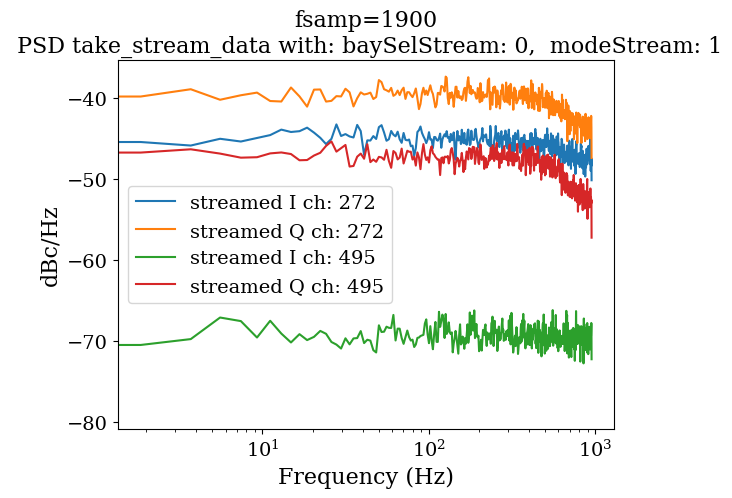

In [29]:
nperseg=2**10
fsamp = 1900
#channels = np.nonzero(not_phase[:416])[0]
channels = S.which_on(0)
print(channels)
for i, row in enumerate(not_phase):
    row1 = row
    I = row1.real
    Q = row1.imag
    ffi,pxxi = welch(I,fs=fsamp,nperseg=nperseg)
    ffq,pxxq = welch(Q,fs=fsamp,nperseg=nperseg)
    # scale to dBc/Hz by the voltage magnitude
    magfac = np.mean(Q)**2 + np.mean(I)**2
    pxxi_dbc = 10. * np.log10(pxxi / magfac)
    pxxq_dbc = 10. * np.log10(pxxq / magfac)
    plt.semilogx(ffi,pxxi_dbc, label=f'streamed I ch: {channels[i]}')
    plt.semilogx(ffq,pxxq_dbc, label=f'streamed Q ch: {channels[i]}')

    
plt.gca().set_aspect('equal')
plt.ylabel('dBc/Hz')
plt.xlabel('Frequency (Hz)')
plt.title( "fsamp=1900\n PSD take_stream_data with: baySelStream: 0,  modeStream: 1")
plt.legend()

/usr/lib/python3/dist-packages/matplotlib/cbook/__init__.py:1390: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


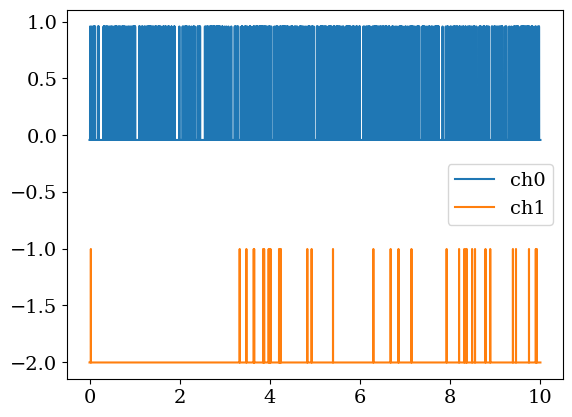

In [30]:
for ch in range(len(not_phase)):
    plt.plot((t-t[0])/1.e9,not_phase[ch]-np.mean(not_phase[ch])-2*ch,label=f'ch{ch}')
plt.legend()
plt.show()

In [31]:
# Sample rate (can't go above 38ish)
S.flux_ramp_setup(38.0,0) # first number in kHz, 2nd number only matters for uMUX

# Configure filter / downsample
S.set_filter_disable(True)
S.set_downsample_factor(1)

print(f'S.get_sample_frequency()={S.get_sample_frequency()}')
print(f'S.get_downsample_factor()={S.get_downsample_factor()}')
print(f'S.get_filter_disable()={S.get_filter_disable()}')

[ 2026-03-06 00:43:27 ]  Percent full scale = 0.000%
S.get_sample_frequency()=38000.9896091044
S.get_downsample_factor()=1
S.get_filter_disable()=1


In [32]:
# loss counter tells you if you lost any frames btw rfsoc and pcie card.  
# Very unlikely at these channel counts, but good to check.
loss0 = S.get_frame_loss_cnt()
fname = S.take_stream_data(10,IQ_mode=True) # also dump a short full stream during this - use the `streamingInterface`
loss1 = S.get_frame_loss_cnt()
print(f'Frames lost = {loss1-loss0} should be zero.')

[ 2026-03-06 00:43:32 ]  Starting to take data.
[ 2026-03-06 00:43:32 ]  Input downsample factor is None. Using value already in pyrogue: 1
[ 2026-03-06 00:43:32 ]  CryoCard.do_read failed, retry 1 / 5.
[ 2026-03-06 00:43:32 ]  CryoCard.do_read failed, retry 2 / 5.
[ 2026-03-06 00:43:32 ]  CryoCard.do_read failed, retry 3 / 5.
[ 2026-03-06 00:43:32 ]  CryoCard.do_read failed, retry 4 / 5.
[ 2026-03-06 00:43:32 ]  CryoCard.do_read failed, retry 5 / 5.
[ 2026-03-06 00:43:32 ]  flux_ramp_ac_dc_relay status: Failed to read from cryo card.
[ 2026-03-06 00:43:32 ]  flux_ramp_ac_dc_relay_status = None - NOT A VALID STATE.
[ 2026-03-06 00:43:37 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Unwrapper:reset 1
[ 2026-03-06 00:43:37 ]  caput smurf_server_s3:AMCc:SmurfProcessor:Filter:reset 1
[ 2026-03-06 00:43:37 ]  Writing to file : /data/smurf_data/20260306/1772757282/outputs/1772757817.dat
[ 2026-03-06 00:43:37 ]  /data/smurf_data/20260306/1772757282/outputs/1772757817_mask.txt
[ 2026-03-06 00:4

In [33]:
print(fname)
filesize_MB = os.path.getsize(fname)/1024**2
print(f'file size: {filesize_MB} MB')

/data/smurf_data/20260306/1772757282/outputs/1772757817.dat
file size: 41.48103332519531 MB


In [34]:
S.get_processed_channels(0)

array([  0,   2,   3,   4,   5,   6,   7,   8,  10,  11,  12,  13,  15,
        16,  18,  19,  20,  21,  22,  23,  24,  26,  27,  28,  29,  31,
        32,  34,  35,  36,  37,  38,  39,  40,  42,  43,  44,  45,  47,
        48,  50,  51,  52,  53,  55,  56,  57,  58,  59,  60,  61,  63,
        64,  66,  67,  68,  69,  70,  71,  72,  74,  75,  76,  77,  79,
        80,  82,  83,  84,  85,  87,  88,  89,  90,  91,  92,  93,  95,
        96,  98,  99, 100, 101, 102, 103, 104, 106, 107, 108, 109, 111,
       112, 114, 115, 116, 117, 119, 120, 121, 122, 123, 124, 125, 127,
       128, 130, 131, 132, 133, 134, 135, 136, 138, 139, 140, 141, 143,
       144, 146, 147, 148, 149, 151, 152, 153, 154, 155, 156, 157, 159,
       160, 162, 163, 164, 165, 166, 167, 168, 170, 171, 172, 173, 175,
       176, 178, 179, 180, 181, 183, 184, 185, 186, 187, 188, 189, 191,
       192, 194, 195, 196, 197, 198, 199, 200, 202, 203, 204, 205, 207,
       208, 210, 211, 212, 213, 215, 216, 217, 218, 219, 220, 22

[ 2026-03-06 00:44:50 ]  Reading /data/smurf_data/20260306/1772757282/outputs/1772757817.dat
Processing data records from /data/smurf_data/20260306/1772757282/outputs/1772757817.dat
[ 2026-03-06 00:44:50 ]  2048 elements loaded
[ 2026-03-06 00:44:50 ]  4096 elements loaded
[ 2026-03-06 00:44:51 ]  6144 elements loaded
[ 2026-03-06 00:44:51 ]  8192 elements loaded
[ 2026-03-06 00:44:51 ]  10240 elements loaded
[ 2026-03-06 00:44:51 ]  12288 elements loaded
[ 2026-03-06 00:44:51 ]  14336 elements loaded
[ 2026-03-06 00:44:52 ]  16384 elements loaded
[ 2026-03-06 00:44:52 ]  18432 elements loaded
[ 2026-03-06 00:44:52 ]  20480 elements loaded
[ 2026-03-06 00:44:52 ]  22528 elements loaded
[ 2026-03-06 00:44:52 ]  24576 elements loaded
[ 2026-03-06 00:44:52 ]  26624 elements loaded
[ 2026-03-06 00:44:53 ]  28672 elements loaded
[ 2026-03-06 00:44:53 ]  30720 elements loaded
[ 2026-03-06 00:44:53 ]  32768 elements loaded
[ 2026-03-06 00:44:53 ]  34816 elements loaded
[ 2026-03-06 00:44:53 ]

/usr/local/lib/python3.8/dist-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


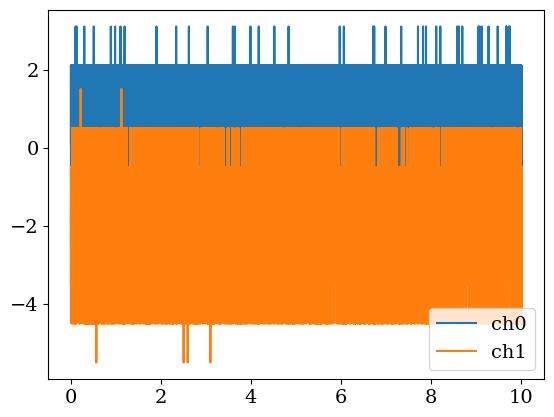

In [35]:
t,d,m = S.read_stream_data(fname,IQ_mode=True)

for ch in range(len(d)):
	plt.plot((t-t[0])/1.e9,d[ch]-np.mean(d[ch])-2*ch,label=f'ch{ch}')
plt.legend()
plt.show()

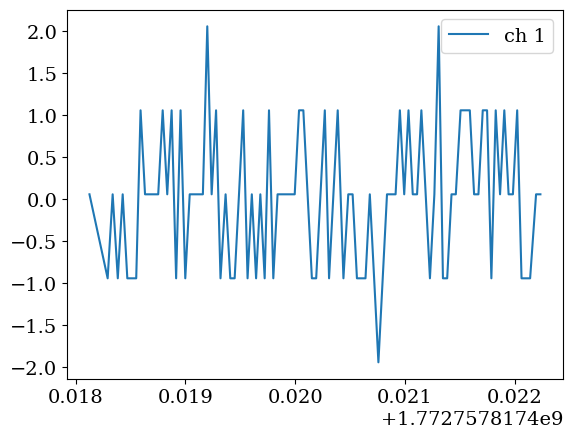

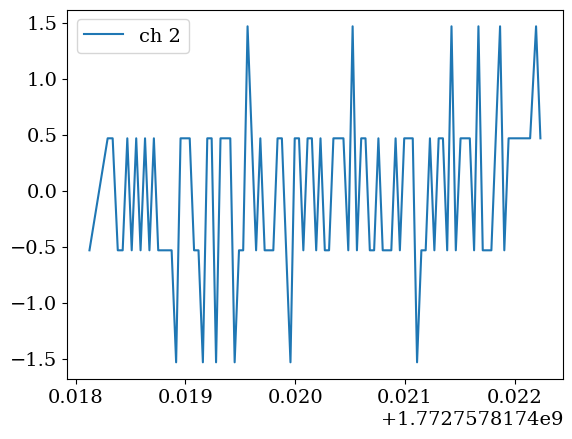

In [36]:
#plot first 100 values
plt.plot((t[0:100])/1.e9, d[0][0:100]-np.mean(d[0][0:100]), label = f'ch 1')
plt.legend()
plt.show()

#plot first 100 values
plt.plot((t[0:100])/1.e9, d[1][0:100]-np.mean(d[1][0:100]), label = f'ch 2')
plt.legend()
plt.show()